# Chapter 21: Introducing DisSModel

*Part IV — DisSModel: Core and Paradigms*

## Learning Objectives

By the end of this chapter you will be able to:

- Explain why DisSModel exists and what problem it solves
- Install DisSModel and its extension packages
- Run two real example models and watch them live, using DisSModel's built-in `Chart` and `Map` components
- Know that reproducibility is one of DisSModel's core design goals, with the framework's full answer to it built in Chapter 22


In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Every technique since Chapter 17 has been building a spatial model largely by hand — a raw NumPy grid, a hand-written neighbor loop, a `salabim` event queue assembled one piece at a time. This chapter's only job is to get DisSModel installed and make the case that it's worth using: no lifecycle deep-dive, no model construction from scratch, just two of the framework's own example models running live, with real visualization, so there's something worth understanding before Chapter 22 opens the hood.


## Why DisSModel

DisSModel is the Python-native successor to TerraME/LuccME, the modeling framework this book's own research group has developed since 2024. TerraME, written in Lua, was a capable and influential platform for two decades of spatial modeling research in Brazil — but Lua sits outside the Python scientific ecosystem this book has spent twenty chapters building fluency in. Every model written in TerraME had to either stay isolated from `pandas`, `geopandas`, and the rest of that world, or be translated by hand.

DisSModel's founding bet is that a modeling framework should live *inside* that ecosystem rather than beside it. Three principles follow directly from that bet, and reappear throughout Part IV:

- **Open** — source available, openly licensed, built to be read and extended, not just called.
- **Interoperable** — a model's state is a `GeoDataFrame` or a NumPy-backed raster, the same objects Part II already made fluent, not a framework-specific data type requiring its own import/export step.
- **Reproducible by construction** — not an afterthought bolted on later, but a contract (Chapter 22's `ModelExecutor`) that every model satisfies from the start.

The map below shows that lineage for the whole ecosystem at once: each TerraME piece on the left, its DisSModel counterpart on the right, grouped by role — core, didactic packages, domain models, data preparation, infrastructure — and marked by how mature each one is today. It is an early snapshot: most packages are just getting started, and boundaries and APIs will change as the work progresses.

<img src="../../assets/images/dissmodel_ecosystem.svg" alt="DisSModel ecosystem map: TerraME and LuccME on the left, their DisSModel counterparts on the right, grouped into core, didactic, domain, data-preparation and infrastructure packages" style="background: white; padding: 12px; border-radius: 8px; max-width: 100%;">

*The DisSModel ecosystem and its TerraME counterparts. Also on the project site, [dissmodel.github.io](https://dissmodel.github.io/).*

Chapter 32 returns to this lineage directly, with a concept-by-concept migration guide for anyone bringing an existing TerraME or LuccME model across.

## Installation

`dissmodel` itself is published on PyPI:

```bash
pip install dissmodel
```

Extension packages such as `dissmodel-ca` and `dissmodel-sysdyn` — the ones the rest of this chapter runs — are **not** published on PyPI; install them straight from GitHub, either the development branch or a released tag:

```bash
pip install "git+https://github.com/DisSModel/dissmodel-ca.git"
pip install "git+https://github.com/DisSModel/dissmodel-sysdyn.git"
```

If you're working from a local clone of an extension repo instead — to run its bundled `examples/`, or to modify it — install it in editable mode from inside the repo:

```bash
git clone https://github.com/DisSModel/dissmodel-ca.git
cd dissmodel-ca
pip install -e .
```

Both patterns slot directly into the `venv` workflow Chapter 5 already established — nothing about DisSModel changes how you'd manage a Python environment. Everything below assumes both packages are already installed.

## Watching a Model Run: Chart and Map

DisSModel ships two small visualization components, `Chart` and `Map`. Both are just `Model` subclasses: construct one against the same `Environment` as the model itself, and it redraws automatically at every tick, with no plotting loop to write by hand.

The two models below are real, pre-built examples from DisSModel's own extension packages: `FireModel` (`dissmodel_ca`, a spatial cellular automaton) and `SIR` (`dissmodel_sysdyn`, a system-dynamics epidemic model). Neither is explained here — `FireModel`'s spreading rule is Chapter 24's opening example, and `SIR`'s equations are Chapter 23's. The point of running them now is simply to see DisSModel do something worth learning more about: whatever a model actually computes, `Chart` and `Map` don't need to know anything about it beyond a column name.

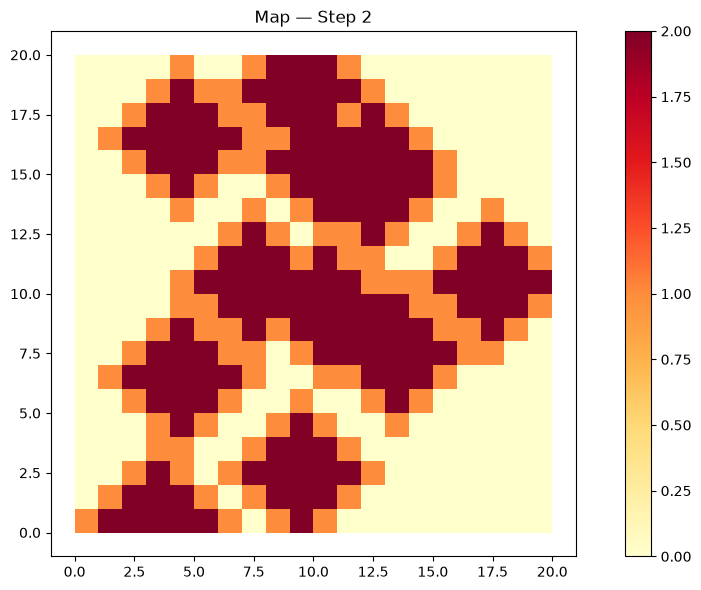

In [3]:
from dissmodel.core import Environment
from dissmodel.geo import vector_grid
from dissmodel.visualization import Map
from dissmodel_ca.models import FireModel

grid = vector_grid(dimension=(20, 20), resolution=1, attrs={"state": 0})

env = Environment(end_time=2)
fire = FireModel(gdf=grid, initial_fire_density=0.02)
fire.initialize()
Map(gdf=grid, plot_params={"column": "state", "cmap": "YlOrRd", "legend": True})

env.run()


`Map` just needed `gdf` — the same `GeoDataFrame` `FireModel` is mutating every tick — and a `plot_params` dict forwarded straight to `GeoDataFrame.plot()`, exactly as Chapter 15 used directly. `FireModel` itself is a `CellularAutomaton`, a `Model` subclass with a couple of extra pieces (`rule()`, a neighborhood); Chapter 24 opens with this identical class and finally explains what `rule()` is doing.

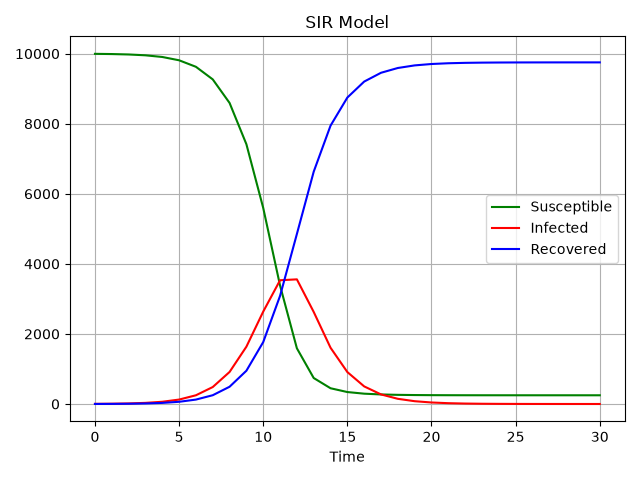

In [4]:
from dissmodel.visualization import Chart
from dissmodel_sysdyn.models import SIR

env = Environment(end_time=30)
sir = SIR()
Chart(show_legend=True, show_grid=True, title="SIR Model")

env.run()


`Chart` needed even less — no `gdf` at all, since `SIR` isn't spatial. It found `susceptible`, `infected`, and `recovered` automatically, via a `@track_plot` decorator on the `SIR` class itself (visible in its source on GitHub, linked below) rather than anything passed to `Chart`'s constructor. Chapter 23 covers `SIR` and `@track_plot` both, alongside several more system-dynamics models from the same `dissmodel_sysdyn` package — `PredatorPrey` and `Daisyworld` among them. Chapter 24 does the same for `FireModel`'s neighbors: `GameOfLife` and a dozen other cellular automata.

## Reproducibility, Briefly

*Why DisSModel* above named reproducibility as one of the framework's founding goals, not an afterthought. `ModelExecutor` is where that goal becomes a concrete contract — a stricter, four-phase layer (`validate → load → run → save`) on top of the `Model` lifecycle Chapter 22 covers in full, built specifically so a model's results stay auditable long after it ran. This chapter doesn't build one; Chapter 22 does, end to end, around a real fire-spread model, and Chapter 28 returns to the provenance side of that same contract in depth.


## Exercises

1. **Install and confirm.** Follow *Installation* above in a fresh virtual environment, then re-run the `SIR` + `Chart` cell and confirm it draws three colored lines.
2. **Change one parameter.** Re-run the `FireModel` example with `initial_fire_density=0.15` and `end_time=4`. Without reading `FireModel`'s source, predict in a sentence what should look different — then check.
3. **Swap the visualization, not the model.** Re-run the `FireModel` example with `Map`'s `cmap` changed to `"Greens"`. Nothing about the simulation itself changes — only describe what changes about how it looks.
4. **Checksums, by hand.** Using Python's `hashlib`, compute the SHA-256 checksum of a small text file you create. What would change about that checksum if you changed a single character in the file? What does that tell you about what a checksum can and can't prove?


In [4]:
# Your code here

## Summary

### Key concepts introduced

- Why DisSModel exists: a Python-native successor to TerraME/LuccME, built to live inside the scientific Python ecosystem rather than beside it
- Installing `dissmodel` from PyPI and extension packages such as `dissmodel-ca`/`dissmodel-sysdyn` from GitHub, within the `venv` workflow Chapter 5 established
- `Chart` and `Map` — ordinary `Model` subclasses that redraw automatically at every tick, demonstrated (not yet explained) against two real example models: `FireModel` (`dissmodel_ca`) and `SIR` (`dissmodel_sysdyn`)
- Reproducibility as one of DisSModel's founding goals, with `ModelExecutor`'s four-phase contract named as the framework's answer to it, explained in full in Chapter 22

Chapter 22 opens the hood: the `Model` lifecycle in detail, building a model one hook at a time, and everything reproducibility actually requires.


## Further Reading

- DisSModel on GitHub: <https://github.com/DisSModel/dissmodel>
- dissmodel-ca on GitHub, source for `FireModel` and this chapter's other cellular automata: <https://github.com/DisSModel/dissmodel-ca>
- dissmodel-sysdyn on GitHub, source for `SIR` and `@track_plot`: <https://github.com/DisSModel/dissmodel-sysdyn>
- TerraME on GitHub, including the course this book's Part III drew several exercises from: <https://github.com/TerraME/terrame>
- The dissmodel-book's own account of this same material, for a different framing of the same ideas: <https://dissmodel.github.io/dissmodel-book/>